# Lab 0d — A bucket: your first *time-dependent* model

<a class="btn btn-primary btn-sm" href="https://dhruvbalwada.github.io/intro-climate-modeling-fall2026/labs/lab0d_bucket.ipynb" download>&#8681; Download this notebook (.ipynb)</a>

*Then upload it to [leap.2i2c.cloud](https://leap.2i2c.cloud/) and open it there.*

*Week 1, in class · Introduction to Climate Modeling*

## 1. A budget

Now let's build our first model based on some physical principles: a bucket of water. 
While quite obvious (due to our intuition of the physical world), the volume in this bucket is conserved if we don't add or remove any water. This is called a "conservation law". 

With water pouring in and draining out, we can track the volume of water, $V = A\,h$:

$$\underbrace{A\,\frac{dh}{dt}}_{\text{accumulation}} \;=\; \underbrace{F}_{\text{in}} \;-\; \underbrace{Q}_{\text{out}}$$

- $h$ = water level [m], $A$ = bucket area [m²]
- $F$ = inflow [m³/s] — **someone pours.** The bucket doesn't decide: this is *external forcing*
- $Q$ = outflow [m³/s] — **the bucket decides**, based on its own state and the properties of the hole.

-> The inflow is imposed; the outflow is the system *responding to itself* — a **feedback**. 

So $Q$ depends on the system. But *how* is a question about physics — and different plumbing at the outflow gives different answers.

## 2. Two drain laws, from first principles

Different properties of the drain can give different flow rates, not just the size of the drain but also whether it is a hole or a pipe. 

We can figure out these outflow using a commonly used approach, which will be used in many laws in this course: **decide which two effects dominate, assume they balance, and neglect the rest.** Physicists call this a *dominant balance*. The two cases differ only in which balance we assume.

### A hole in the bucket — nothing resists (Torricelli's law)

Water leaves through a hole of area $a$ with nothing to rub against, so nothing dissipates its energy. 

Take a parcel of water at the surface, a height $h$ above the hole, and let it make its way down: assume that all the potential energy it gives up gets converted to motion (or kinetic energy), exactly as for a dropped ball.

$$\underbrace{m g h}_{\text{potential energy released}} \;=\; \underbrace{\tfrac{1}{2} m v^{2}}_{\text{kinetic energy gained}} \quad\Longrightarrow\quad v = \sqrt{2gh}$$

**The balance we just assumed:** *all* of the released potential energy becomes motion — nothing is lost to friction. Inertia dominates; viscosity is neglected.

The volume leaving per second [m³/s] is then the outflow jet's speed times the area it flows through:

$$Q = a\,v = a\sqrt{2gh} \;\propto\; \sqrt{h}$$

Note that: **$A$ is the bucket's cross-section, $a$ is the opening's** — and $a \ll A$.

This is **Torricelli's law** (1643): the jet leaves at exactly the speed it would have had if it had fallen freely from the surface. 

> ***Aside — the same result, done more carefully (Bernoulli).***
>
> The falling-parcel argument gets the right answer, but the water is not actually in free fall — it is being pushed out by the weight of everything above it. The honest version follows a streamline from the free surface (point 1) to the jet (point 2) and uses **Bernoulli's equation**, which says that without dissipation the sum of pressure, kinetic and potential terms is unchanged along the way:
>
> $$P_1 + \tfrac12\rho v_1^2 + \rho g z_1 \;=\; P_2 + \tfrac12\rho v_2^2 + \rho g z_2$$
>
> Three facts collapse it. The surface is open to the air and the jet emerges into the air, so $P_1 = P_2$ and **the pressures cancel**. The bucket is far wider than the hole, so the surface descends slowly and $v_1 \approx 0$. Measuring height from the hole, $z_1 = h$ and $z_2 = 0$. What survives is $\rho g h = \tfrac12 \rho v^{2}$ — the same $v=\sqrt{2gh}$.
>
> Two things this version makes visible that the falling-ball picture hides: what actually drives the jet (**the pressure of the water column**, with the atmosphere cancelling from both ends), and the assumption we are leaning on (**no viscous dissipation**, without which Bernoulli's equation does not apply) — which is precisely what stops being true in the next case.

### A narrow tube instead — viscosity resists (Poiseuille's law)

Replace the hole with a long thin pipe — radius $r$, length $L$, so the same opening area $a=\pi r^{2}$. In such a pipe the water is not free to move easily, and the friction or viscosity at the pipe wall starts to become important. 

Fluid touching a solid surface does not slide along it — it sticks. (This is the **no-slip condition**, an experimental fact about fluids and walls.) So inside the tube the water is stationary at the wall and fastest in the middle: neighbouring layers of fluid are sliding past one another.

Viscosity is the resistance to exactly that sliding. **Newton's law of viscosity** says the drag force per unit area between layers is proportional to how rapidly velocity changes across the flow:

$$\tau \;=\; \mu \frac{dv}{dy} \;\sim\; \mu \frac{v}{r}$$

Checking the units keeps us honest here:

- $\tau$ is a **stress** — a force spread over an area: [N m⁻²] = [Pa] = [kg m⁻¹ s⁻²]
- $dv/dy$ is a **velocity gradient** — a speed divided by a distance: [(m s⁻¹)/m] = [s⁻¹]
- so $\mu$, the **dynamic viscosity**, must carry [Pa s] = [kg m⁻¹ s⁻¹]

For water $\mu \approx 1\times10^{-3}$ Pa s; air is about 50 times less viscous, honey about 10,000 times more.

We used $v/r$ as a "scaling" assuming that the speed goes from roughly $v$ at the centre to zero at the wall, across a distance of about the tube radius $r$. That stress acts over the whole inner wall of the tube, area $2\pi r L$, so the total resisting force is $\mu (v/r)\cdot 2\pi r L$.

Meanwhile the water is pushed along by the **pressure** of the column standing above the tube. In this case we can estimate the pressure as the force exerted by the weight of the fluid per unit area. So pressure on the inside is:

$$P \;=\; \frac{\text{weight of the column}}{\text{area}} \;=\; \frac{\rho\,A\,h\,g}{A} \;=\; \rho g h
\qquad [\text{kg m}^{-3}][\text{m s}^{-2}][\text{m}] = [\text{kg m}^{-1}\text{s}^{-2}] = [\text{Pa}]$$

The pressure at the bottom of a bucket does not care how wide the bucket is — only how deep the water is. Pressure is also just a number at every point in the fluid, and acts equally in all directions, so pressure due to weight of water above the hole acts the same way into the hole.
This pressure acts on the tube's cross-section $\pi r^2$.

**The balance is now a force balance**: the pressure force is opposed by viscous drag, and the two are in equilibrium. Nothing accelerates — the flow settles at whatever speed makes push and drag equal. Here viscosity dominates and inertia is neglected, the *opposite* choice from Torricelli:

$$\underbrace{\rho g h \cdot \pi r^{2}}_{\text{pressure pushing}} \;\sim\; \underbrace{\mu \frac{v}{r}\cdot 2\pi r L}_{\text{wall drag}} \quad\Longrightarrow\quad v \sim \frac{\rho g h\, r^{2}}{\mu L} \quad\Longrightarrow\quad Q = v\,\pi r^{2} \;\propto\; h$$

The outflow is **linear** in $h$. Notice also $Q \propto r^{4}$: halving the tube radius cuts the flow sixteenfold.

> **Scaling arguments get the form right, not the constant.**
>
> Solving the flow exactly (Poiseuille) gives $Q = \pi r^{4}\rho g h / (8\mu L)$. Our argument got every dependence right and missed only the factor of 8.
>
> Worth keeping: **physics fixes the *form* of a law; the number in front comes from a full solution or from measurement.** Form = the model's *structure*; the number = a *parameter*. Calibrating a model means pinning down the second, not the first.

### The real lesson: laws come from assumed balances

Neither derivation solved the full equations of fluid motion. Each one **picked two terms, set them equal, and threw the rest away**:

| | assumed balance | neglected |
|---|---|---|
| Torricelli | potential energy $\leftrightarrow$ kinetic energy | viscous dissipation |
| Poiseuille | pressure force $\leftrightarrow$ viscous drag | inertia (acceleration) |

Both effects are *always* present. Which one you may neglect depends on the situation — for pipe flow the deciding ratio of inertia to viscosity is the **Reynolds number**. Choose the wrong balance and you get a confident, wrong law.

This is how nearly every equation in this course will be built. Next week we write a balance between absorbed sunlight and emitted infrared, and neglect everything else — and a planet's temperature falls out of it.

### So which law?

 $Q \propto \sqrt{h}$ 
 or $Q \propto h$ ? 

Same bucket, different plumbing, different law. **Choosing the law is a modelling decision** — one to justify from physics and knowledge of the system, not convenience.

For the rest of today we use the **linear** law, $Q = k\,h$, because it is the simplest thing:

$$A\,\frac{dh}{dt} \;=\; F \;-\; k\,h$$

with $k$ [m²/s] the drain constant.

## 3. Equilibrium — no time needed

> **Thought experiment.** What if the drain were a pump running at a fixed rate $c$, regardless of level? Then $A\,dh/dt = F - c$: a constant. The bucket fills forever, or empties forever, and only sits still if $F$ happens to equal $c$ exactly. **Equilibrium exists because outflow grows with level.**

At equilibrium the level isn't changing: $dh/dt = 0$, so inflow = outflow:

$$h^* = F / k$$

**Check the units. Then compute it:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = 1.0    # m^2
F = 2.0    # m^3/s
k = 1.0    # m^2/s

h_star = F / k
print(f"equilibrium level h* = {h_star} m")

equilibrium level h* = 2.0 m


## 4. Step forward in time

The equation tells us the *rate of change* right now. So predict a small step ahead, over and over:

$$h_{\text{next}} = h_{\text{now}} + \Delta t \cdot \frac{F - k\,h_{\text{now}}}{A}$$

*(This is called Euler's method — it's how we march time forward.)*

**Fill in the one missing line:**

> Until you fill it in, the rate of change is zero — so your plot will be a **flat line**. That flat line is the model telling you it has no physics in it yet.


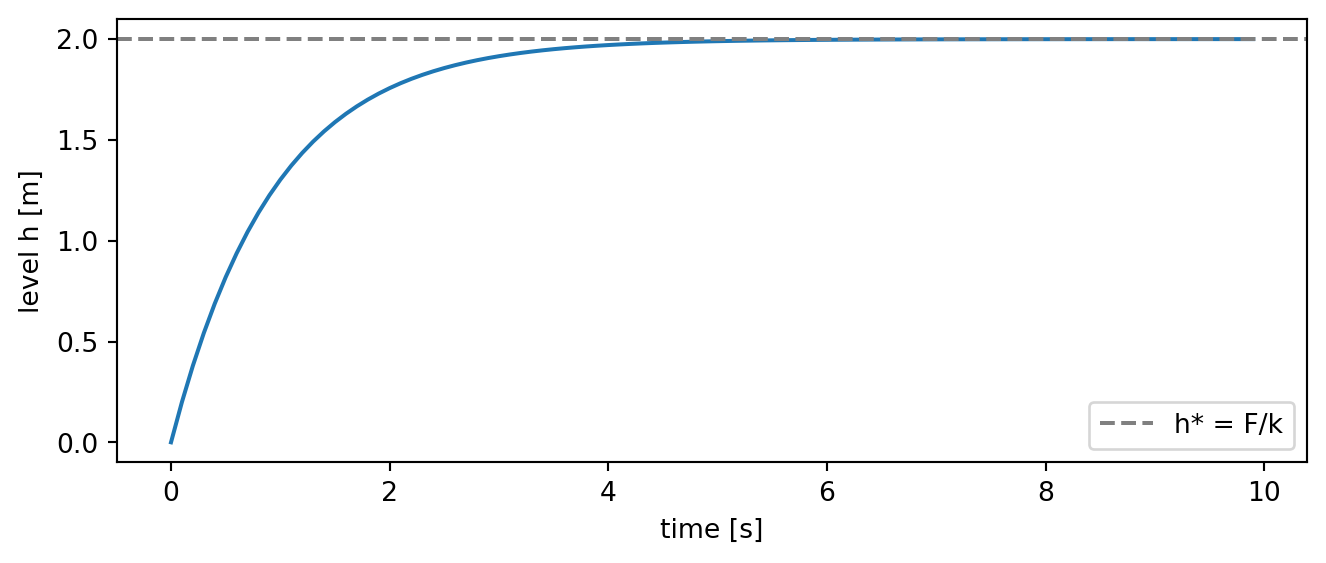

In [2]:
def run_bucket(h0, F, k, A=1.0, dt=0.1, n_steps=100):
    """March the bucket forward from level h0. Returns times and levels."""
    h = np.zeros(n_steps)
    h[0] = h0 # initial condition
    for i in range(1, n_steps):
        h[i] = h[i-1] + dt * (F - k*h[i-1])/A   # <-- FILL THIS IN: what is dh/dt?
    return np.arange(n_steps) * dt, h

t, h = run_bucket(h0=0.0, F=2.0, k=1.0)


plt.figure(figsize=(8, 3))
plt.plot(t, h)
plt.axhline(2.0, ls="--", color="gray", label="h* = F/k")
plt.xlabel("time [s]"); plt.ylabel("level h [m]"); plt.legend();

The level rises and *settles at the equilibrium* — the drain term pulls it there (fuller → drains harder → a **stabilizing feedback**).

## 5. Make predictions — and break them three ways

Our model predicts the level at t = 10 s. How much should we trust that number? Attack it from three directions:

**(a) Initial conditions:** run from `h0 = 0, 1, 3, 5`. Plot all four. Does the prediction at t = 10 s care about where you started? At t = 0.5 s?

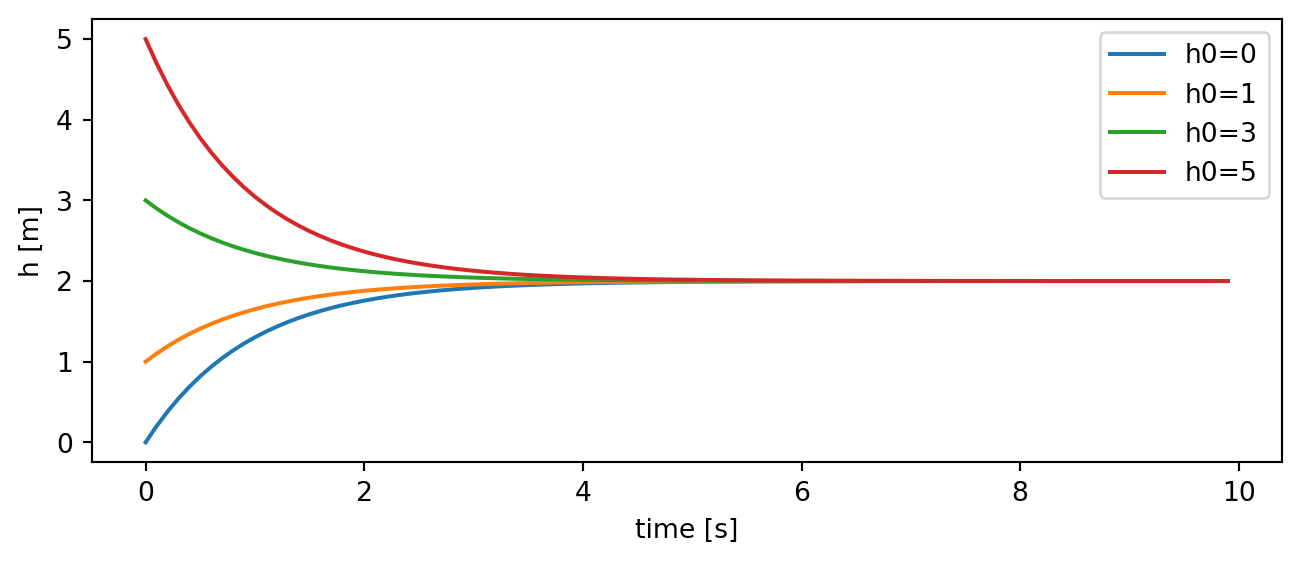

In [3]:
plt.figure(figsize=(8, 3))
for h0 in [0, 1, 3, 5]:
    t, h = run_bucket(h0=h0, F=2.0, k=1.0)
    plt.plot(t, h, label=f"h0={h0}")
plt.xlabel("time [s]"); plt.ylabel("h [m]"); plt.legend();

**(b) Model parameters:** suppose we only know the drain constant roughly: $k = 1.0 \pm 0.2$. Run with `k = 0.8, 1.0, 1.2`. How wide is the prediction at t = 10 s?

In [4]:
# YOUR TURN: copy the loop above, but vary k instead of h0.


**(c) Forcing:** we don't control the pourer. Run with `F = 1.5, 2.0, 2.5`. How wide now?

In [5]:
# YOUR TURN: vary F.


## 6. Name what you just did

You attacked one prediction from three directions. They have official names:

| you varied | uncertainty type | Earth version |
|---|---|---|
| `h0` | **initial-condition** uncertainty | today's exact weather state |
| `k`  | **model** (parameter) uncertainty | how strong are the feedbacks? |
| `F`  | **scenario** uncertainty | what will humans emit? |

**Discuss:** which mattered at short times? Which at long times?

*Before you leave: make sure today's notebooks are saved in your course repo, and your repo link is posted on Courseworks.*
